In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv('weatherAUS.csv')
df = df.dropna(subset=['RainTomorrow'])

df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df = df.drop('Date', axis=1)

X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

numeric_features = X.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[categorical_features]), columns=categorical_features, index=X_train.index)
X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[categorical_features]), columns=categorical_features, index=X_test.index)

num_imputer = SimpleImputer(strategy='median')
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[numeric_features]), columns=numeric_features, index=X_train.index)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[numeric_features]), columns=numeric_features, index=X_test.index)

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_cat_encoded = pd.DataFrame(ohe.fit_transform(X_train_cat), columns=ohe.get_feature_names_out(categorical_features), index=X_train.index)
X_test_cat_encoded = pd.DataFrame(ohe.transform(X_test_cat), columns=ohe.get_feature_names_out(categorical_features), index=X_test.index)

scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=numeric_features, index=X_train.index)
X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num), columns=numeric_features, index=X_test.index)

X_train_processed = pd.concat([X_train_num_scaled, X_train_cat_encoded], axis=1)
X_test_processed = pd.concat([X_test_num_scaled, X_test_cat_encoded], axis=1)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

train_export = X_train_resampled.copy()
train_export['RainTomorrow'] = y_train_resampled

test_export = X_test_processed.copy()
test_export['RainTomorrow'] = y_test.values

train_export.to_csv('train_preprocessed.csv', index=False)
test_export.to_csv('test_preprocessed.csv', index=False)

results_file = 'model_results.csv'

if not os.path.exists(results_file):
    pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1']).to_csv(results_file, index=False)

print("Done")

Done


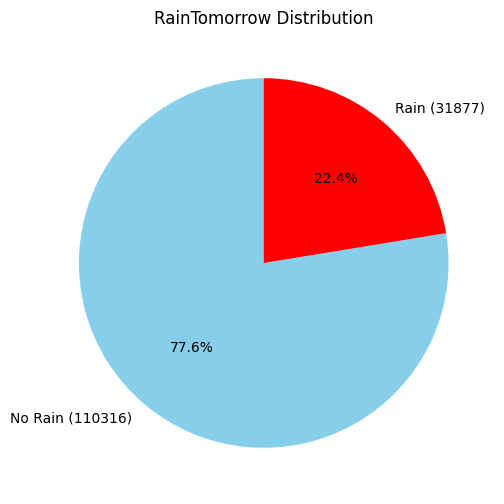

In [2]:
# Rain Tomorrow Distribution
counts = df['RainTomorrow'].value_counts()
labels = ['No Rain', 'Rain']

plt.figure(figsize=(6,6))
plt.pie(counts,
        labels=[f'{l} ({c})' for l, c in zip(labels, counts)],
        autopct='%1.1f%%',
        startangle=90,
        colors=['skyblue', 'red'])
plt.title('RainTomorrow Distribution')

plt.show()

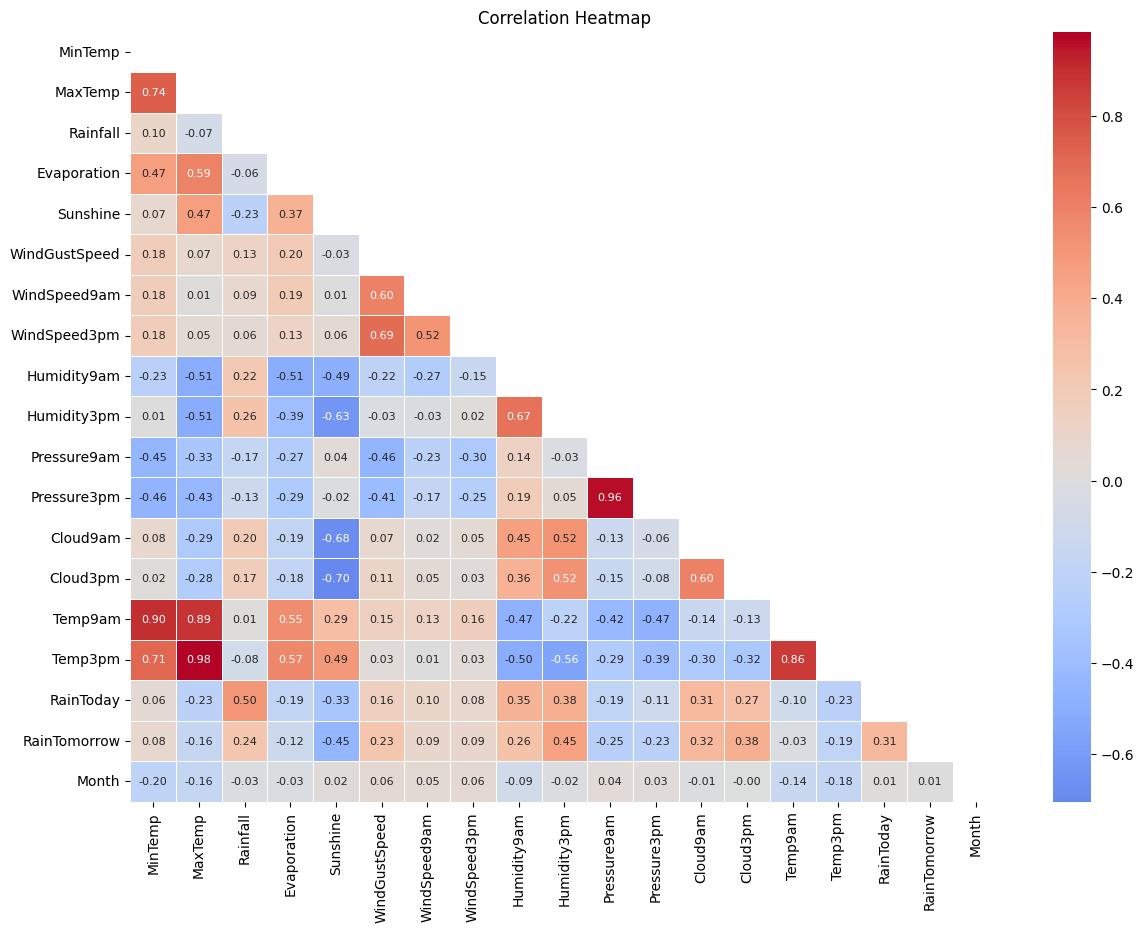

In [3]:
# Correlation heatmap for numeric features
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True,  annot_kws={"size":8}, linewidths=0.5, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

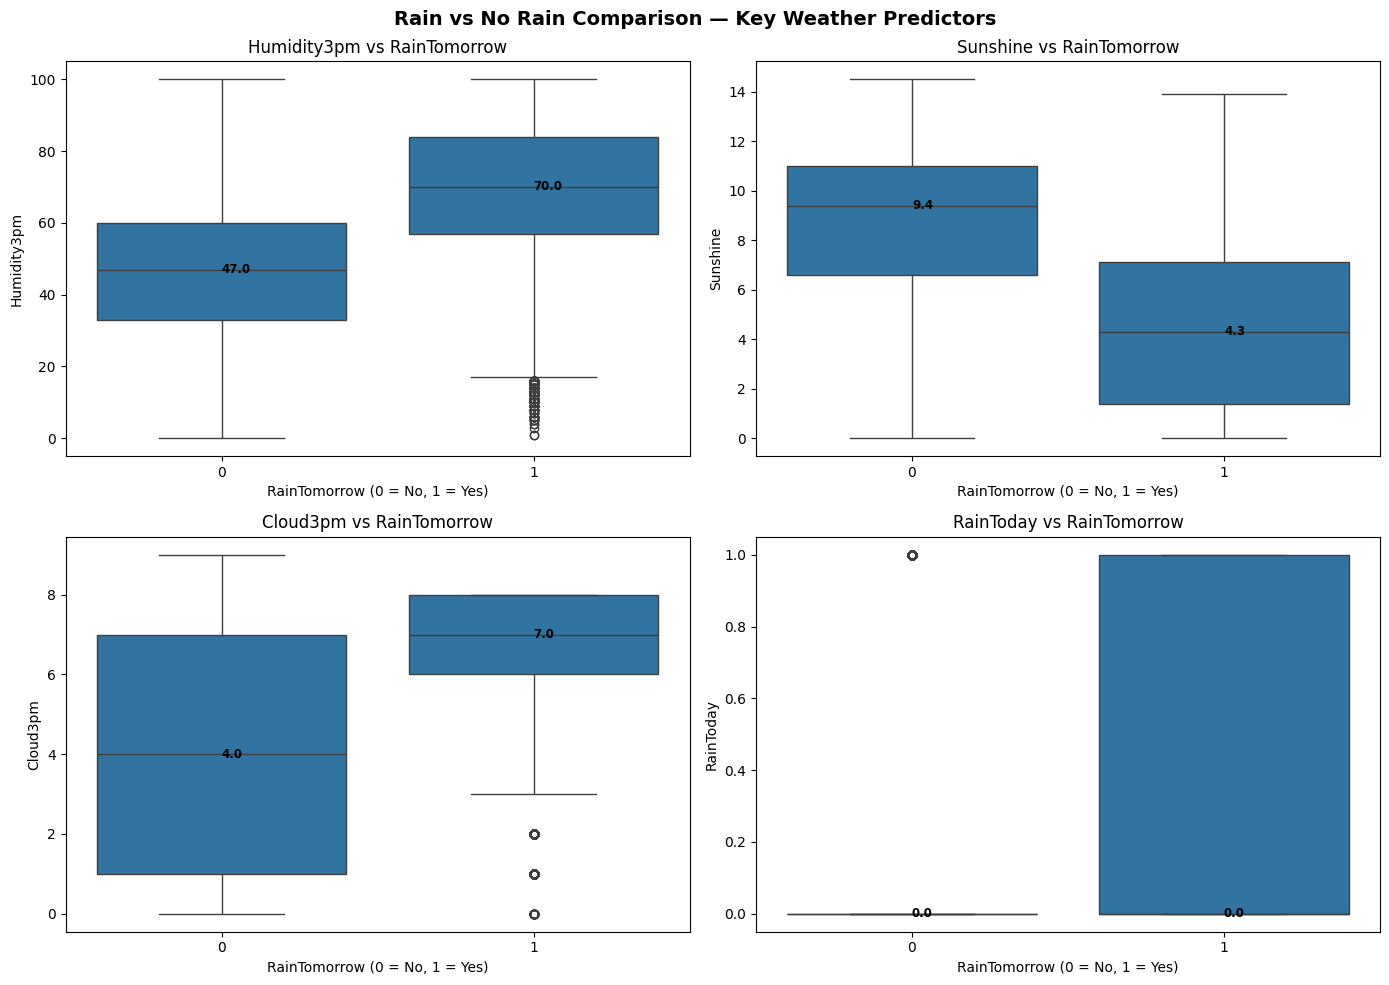

In [4]:
# Rain vs No Rain comparison

features = {
    'Humidity3pm': 'Humidity3pm',
    'Sunshine': 'Sunshine',
    'Cloud3pm': 'Cloud3pm',
    'RainToday': 'RainToday'
}

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, (feature, label) in enumerate(features.items()):
    sns.boxplot(
        x='RainTomorrow',
        y=feature,
        data=df,
        ax=axes[i],
    )

    # Add median labels
    for j, group in enumerate([0, 1]):
        med = df[df['RainTomorrow'] == group][feature].median()
        axes[i].text(
            j, med, f'{med:.1f}',
            va='center',
            fontsize=8.5,
            color='black',
            fontweight='bold'
        )
    
    axes[i].set_title(f'{label} vs RainTomorrow')
    axes[i].set_xlabel('RainTomorrow (0 = No, 1 = Yes)')
    axes[i].set_ylabel(label)

plt.suptitle('Rain vs No Rain Comparison — Key Weather Predictors',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()